<a href="https://colab.research.google.com/github/Hcxgraphics/Police_uniform/blob/main/Police_uniform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [47]:
!pip install tensorflow keras roboflow

In [18]:
!pip install ultralytics roboflow -q


In [5]:
from roboflow import Roboflow
from ultralytics import YOLO
import os
import random
import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [20]:
!pip install roboflow

from roboflow import Roboflow
# rf = Roboflow(api_key="C0kVASbZpIdY9F8FK6Wu")
# project = rf.workspace("hc-w93vm").project("police-uniform")
version = project.version(1)
dataset = version.download("yolov8-obb")


loading Roboflow workspace...
loading Roboflow project...


In [21]:
!unzip /content/police-uniform.v1i.yolov8-obb.zip

Archive:  /content/police-uniform.v1i.yolov8-obb.zip
  inflating: README.dataset.txt      
  inflating: README.roboflow.txt     
  inflating: data.yaml               
   creating: train/
   creating: train/images/
 extracting: train/images/Image_13_jpg.rf.45d8a351d408490e824c405506da5b56.jpg  
 extracting: train/images/Image_13_jpg.rf.847dd2a3900e33111eb83c41e594a55f.jpg  
 extracting: train/images/Image_13_jpg.rf.902036b684b103f73d70c946f4f17434.jpg  
 extracting: train/images/Image_1_jpg.rf.0830fa710262cfef58e6060aaf2d9438.jpg  
 extracting: train/images/Image_1_jpg.rf.34f94791f467cbb9f299919a058e610b.jpg  
 extracting: train/images/Image_1_jpg.rf.a9a53107360500a3e8db8bd64125362a.jpg  
 extracting: train/images/Image_20_jpg.rf.01604b1299d47ccea641f30208408a10.jpg  
 extracting: train/images/Image_20_jpg.rf.76f706af84ad8df8d1f2e056ebe4e92f.jpg  
 extracting: train/images/Image_20_jpg.rf.8f217c17261c5e8fb2fdddc8415ff526.jpg  
 extracting: train/images/Image_23_jpg.rf.083ab780c53ef82df4

In [37]:
# Define the class name and number of classes
class_names = ['police']  # Your single class name
num_classes = len(class_names)

# Create the content for the data.yaml file
yaml_content = f"""
train: /content/dataset/train/images
val: /content/dataset/valid/images

nc: {num_classes}
names: {class_names}
"""

# Write the content to the data.yaml file
yaml_path = os.path.join(dataset.location, "data.yaml")
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"YAML file created at {yaml_path}")



YAML file created at /content/police-uniform-1/data.yaml


In [38]:
# Check the contents of the data.yaml file
with open(yaml_path, 'r') as f:
    print(f.read())

print(f"YAML file created at: {yaml_path}")


train: /content/dataset/train/images
val: /content/dataset/valid/images

nc: 1
names: ['police']

YAML file created at: /content/police-uniform-1/data.yaml


In [39]:
# Load YOLOv8 nano model (small and fast)
model = YOLO('yolov8n.pt')

# Train model
results = model.train(
    data=yaml_path,
    epochs=16,     # Adjust depending on your need
    imgsz=640,
    batch=8,
    name="police_uniform_detection"
)



Ultralytics 8.3.145 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/police-uniform-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=police_uniform_detection4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True,

100%|██████████| 755k/755k [00:00<00:00, 32.9MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 22        [15, 18, 21]  1    751507  ultralytics.nn.modules.head.Detect           [1, [64, 128, 256]]           
Model summary: 129 layers, 3,011,043 parameters, 3,011,027 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 596.5±197.1 MB/s, size: 38.2 KB)


train: Scanning /content/dataset/train/labels... 141 images, 0 backgrounds, 0 corrupt: 100%|██████████| 141/141 [00:00<00:00, 985.88it/s]

...

      15/50         0G      1.179      1.137        1.3         25        640: 100%|██████████| 18/18 [02:05<00:00,  6.97s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:03<00:00,  3.27s/it]

                   all         11         25      0.909       0.92       0.94      0.619



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      16/50         0G      1.137      1.108      1.268         60        640:  72%|███████▏  | 13/18 [01:39<00:38,  7.67s/it]


KeyboardInterrupt: 

Running inference on image: /content/dataset/valid/images/image_21_jpg.rf.25c57507837da3e795972548772c6cdb.jpg

image 1/1 /content/dataset/valid/images/image_21_jpg.rf.25c57507837da3e795972548772c6cdb.jpg: 640x416 1 police, 188.3ms
Speed: 2.9ms preprocess, 188.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 416)


array([[[248, 226, 184],
        [248, 226, 184],
        [248, 226, 184],
        ...,
        [255, 224, 175],
        [255, 224, 175],
        [255, 224, 175]],

       [[248, 226, 184],
        [248, 226, 184],
        [248, 226, 184],
        ...,
        [255, 224, 175],
        [255, 224, 175],
        [255, 224, 175]],

       [[248, 226, 184],
        [248, 226, 184],
        [248, 226, 184],
        ...,
        [255, 224, 175],
        [255, 224, 175],
        [255, 224, 175]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
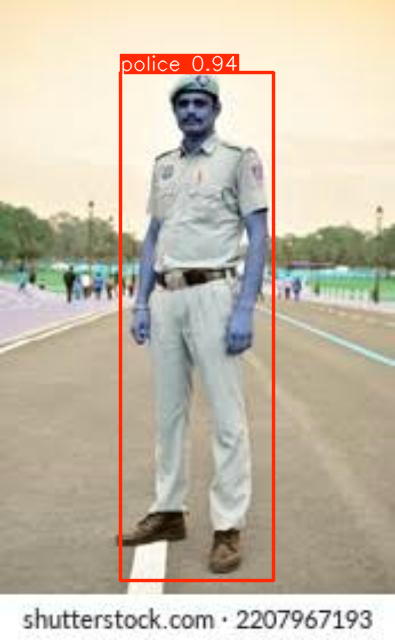

In [42]:
val_images_dir = "/content/dataset/valid/images"
val_images = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.png'))]

img_path = random.choice(val_images)
print(f"Running inference on image: {img_path}")

results = model.predict(img_path)
results[0].plot()


Saving sample_test_img.jpg to sample_test_img (1).jpg
Running detection on sample_test_img (1).jpg

0: 384x640 4 persons, 170.2ms
Speed: 11.1ms preprocess, 170.2ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


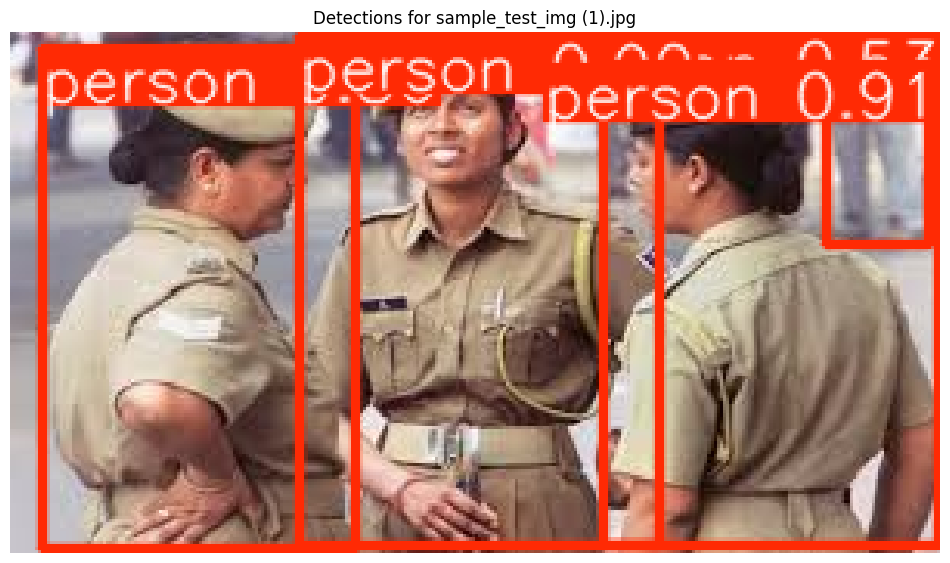

In [46]:
from google.colab import files
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import numpy as np

# Upload images interactively
uploaded_files = files.upload()

# Load best trained YOLOv8-OBB model weights
best_weights = "/content/yolov8n.pt"
model = YOLO(best_weights)

for filename in uploaded_files.keys():
    print(f"Running detection on {filename}")

    # Read image with OpenCV
    img = cv2.imread(filename)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run prediction
    results = model.predict(img_rgb)

    # Annotate image with bounding boxes
    annotated_img = results[0].plot()

    # Display the image with detections
    plt.figure(figsize=(12,8))
    plt.axis('off')
    plt.title(f"Detections for {filename}")
    plt.imshow(annotated_img)
    plt.show()
